<center><b>Stroke Classification</b></center>

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [90]:
df = pd.read_csv('healthcare-dataset-stroke-data.csv')
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [91]:
df.drop(['id'], axis=1, inplace=True)

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 439.3+ KB


In [93]:
df.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


<Axes: >

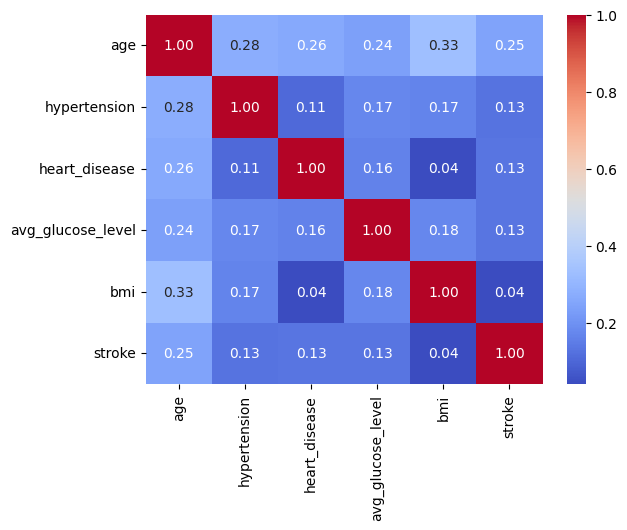

In [94]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')

In [95]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')

In [96]:
df[["bmi"]] = imputer.fit_transform(df[["bmi"]])

In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                5110 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 439.3+ KB


In [98]:
df.tail()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
5105,Female,80.0,1,0,Yes,Private,Urban,83.75,28.893237,never smoked,0
5106,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.000000,never smoked,0
5107,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.600000,never smoked,0
5108,Male,51.0,0,0,Yes,Private,Rural,166.29,25.600000,formerly smoked,0
5109,Female,44.0,0,0,Yes,Govt_job,Urban,85.28,26.200000,Unknown,0


In [99]:
df.nunique().sort_values(ascending=False)

avg_glucose_level    3979
bmi                   419
age                   104
work_type               5
smoking_status          4
gender                  3
hypertension            2
Residence_type          2
ever_married            2
heart_disease           2
stroke                  2
dtype: int64

In [100]:
df["gender"].unique()

array(['Male', 'Female', 'Other'], dtype=object)

<Axes: xlabel='age', ylabel='avg_glucose_level'>

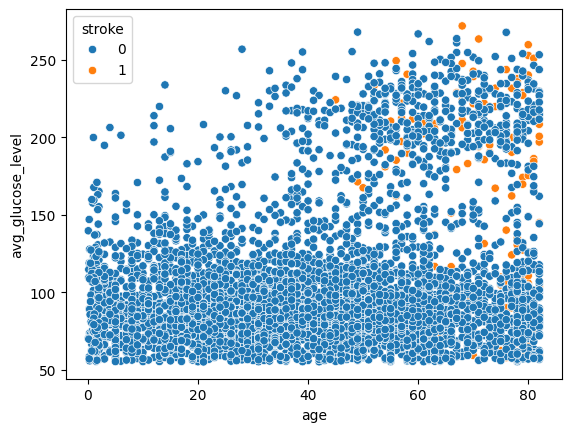

In [101]:
sns.scatterplot(data=df, x='age', y='avg_glucose_level', hue='stroke')

<Axes: xlabel='age', ylabel='bmi'>

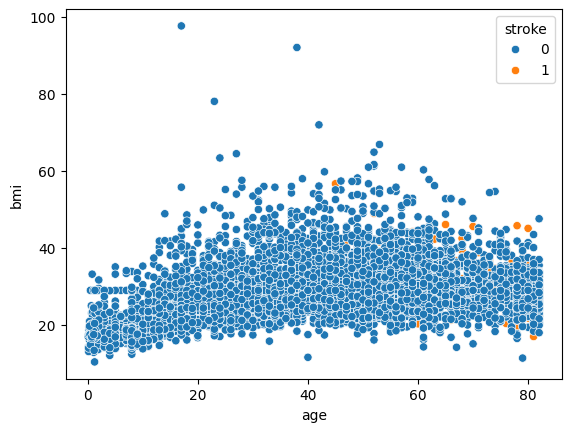

In [102]:
sns.scatterplot(data=df, x='age', y='bmi', hue='stroke')

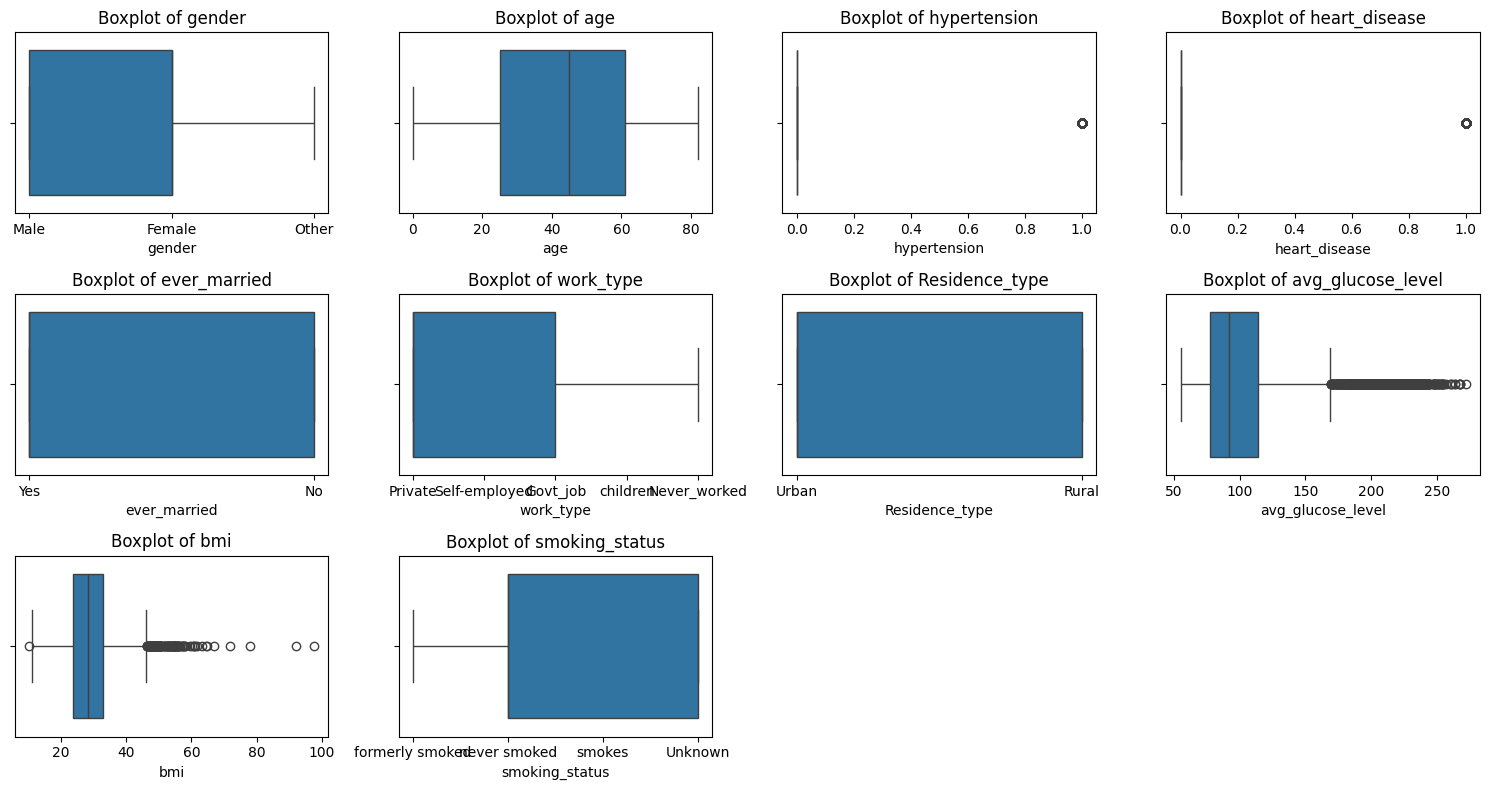

In [103]:
fig,axes = plt.subplots(3,4,figsize=(15,8))
axes = axes.flatten()

for j,col in enumerate(df.columns):
    if col != "stroke":
        sns.boxplot(x=df[col], ax=axes[j])
        axes[j].set_title(f"Boxplot of {col}")
        j += 1
for k in range(j, len(axes)):
    fig.delaxes(axes[k])
    
plt.tight_layout()

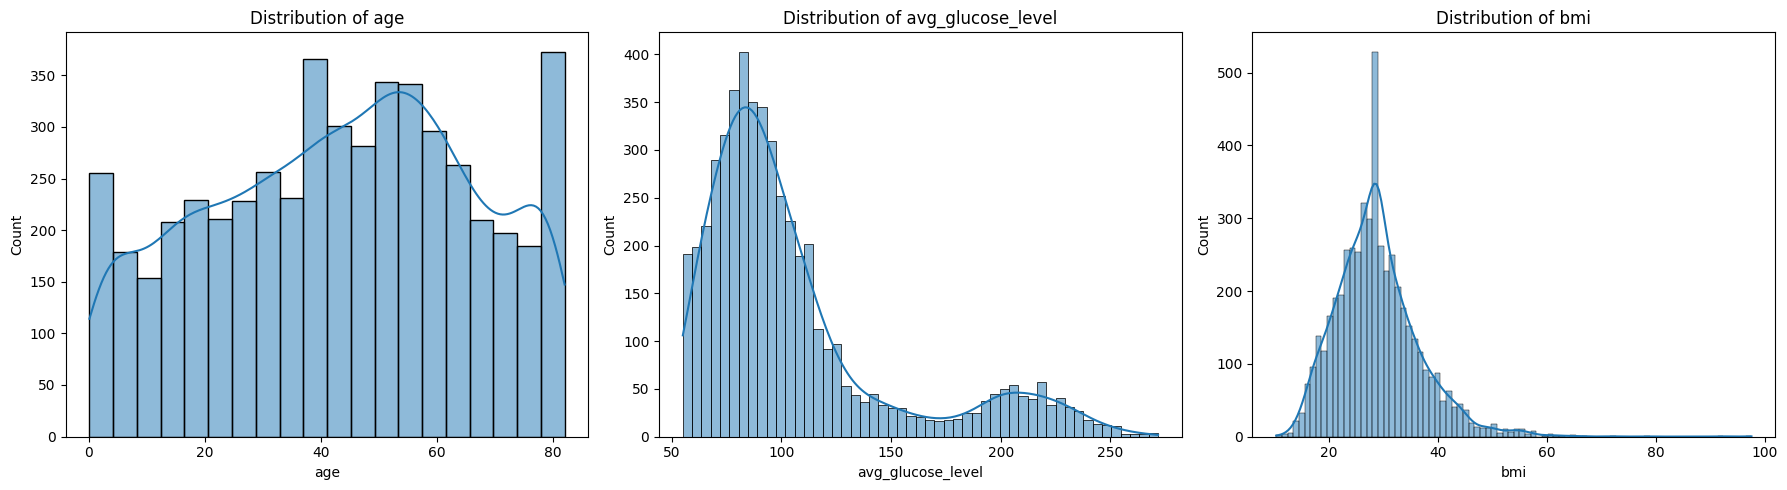

In [104]:
numerical_features = [
    "age",
    "avg_glucose_level",
    "bmi"
]

fig, axes = plt.subplots(1, 3, figsize=(18,5))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

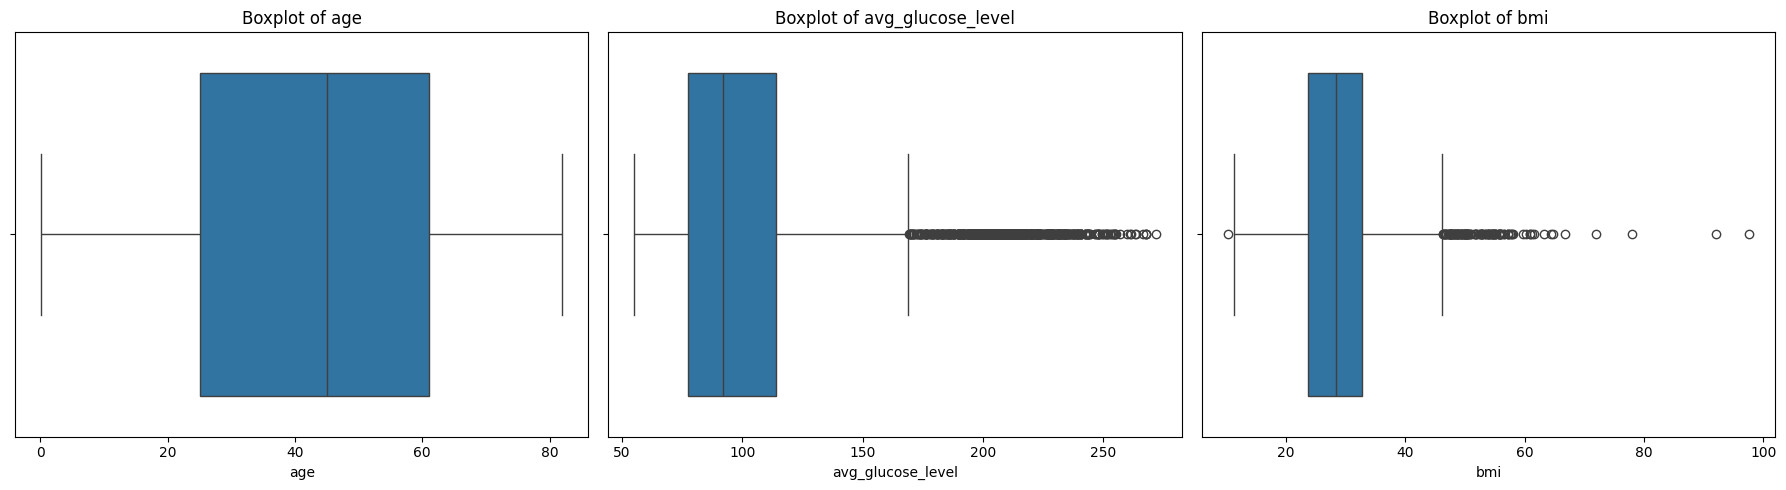

In [105]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

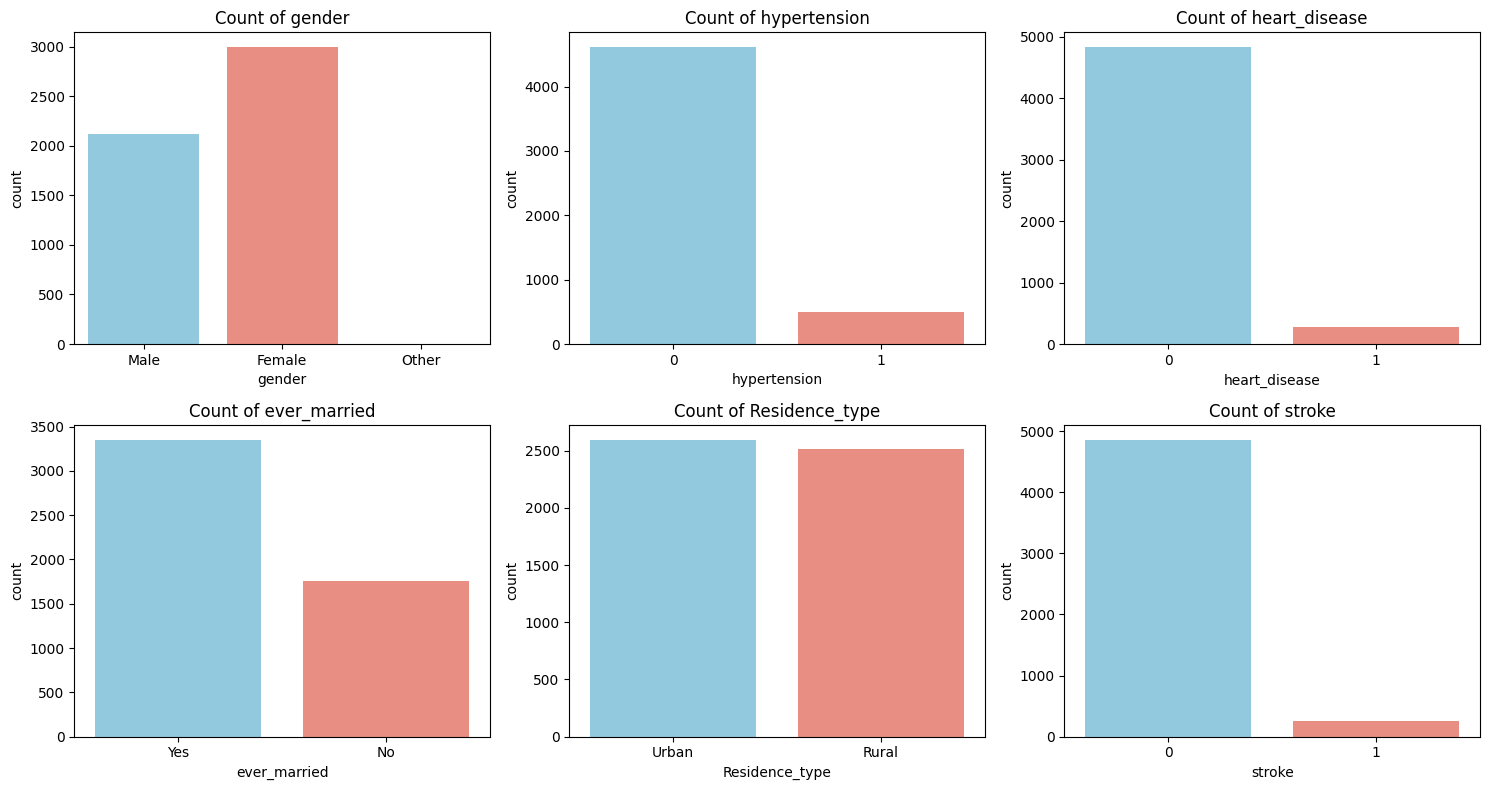

In [106]:
binary_features = [
    "gender",
    "hypertension",
    "heart_disease",
    "ever_married",
    "Residence_type",
    "stroke"
]

fig, axes = plt.subplots(2, 3, figsize=(15,8))
axes = axes.flatten()

for i, col in enumerate(binary_features):
    sns.countplot(x=df[col], ax=axes[i], palette=["skyblue", "salmon"])
    axes[i].set_title(f"Count of {col}")

plt.tight_layout()
plt.show()

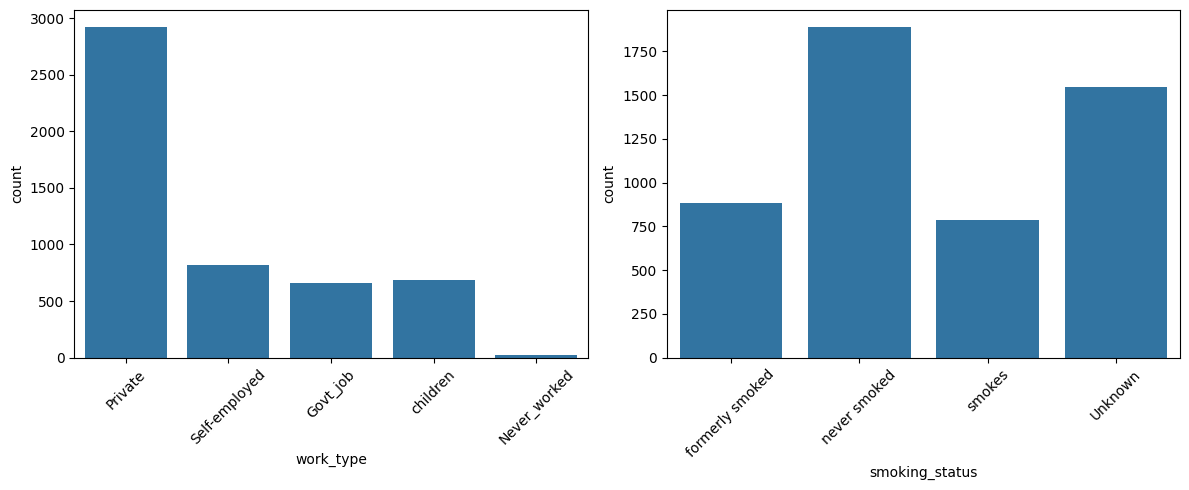

In [107]:
categorical_features = [
    "work_type",
    "smoking_status"
]

fig, axes = plt.subplots(1, 2, figsize=(12,5))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    sns.countplot(x=df[col], ax=axes[i])
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [108]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [109]:
le = LabelEncoder()
categorical_columns = df.select_dtypes(include=['object']).columns
for column in categorical_columns:
    df[column] = le.fit_transform(df[column])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   int64  
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   int64  
 5   work_type          5110 non-null   int64  
 6   Residence_type     5110 non-null   int64  
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                5110 non-null   float64
 9   smoking_status     5110 non-null   int64  
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(8)
memory usage: 439.3 KB


<Axes: >

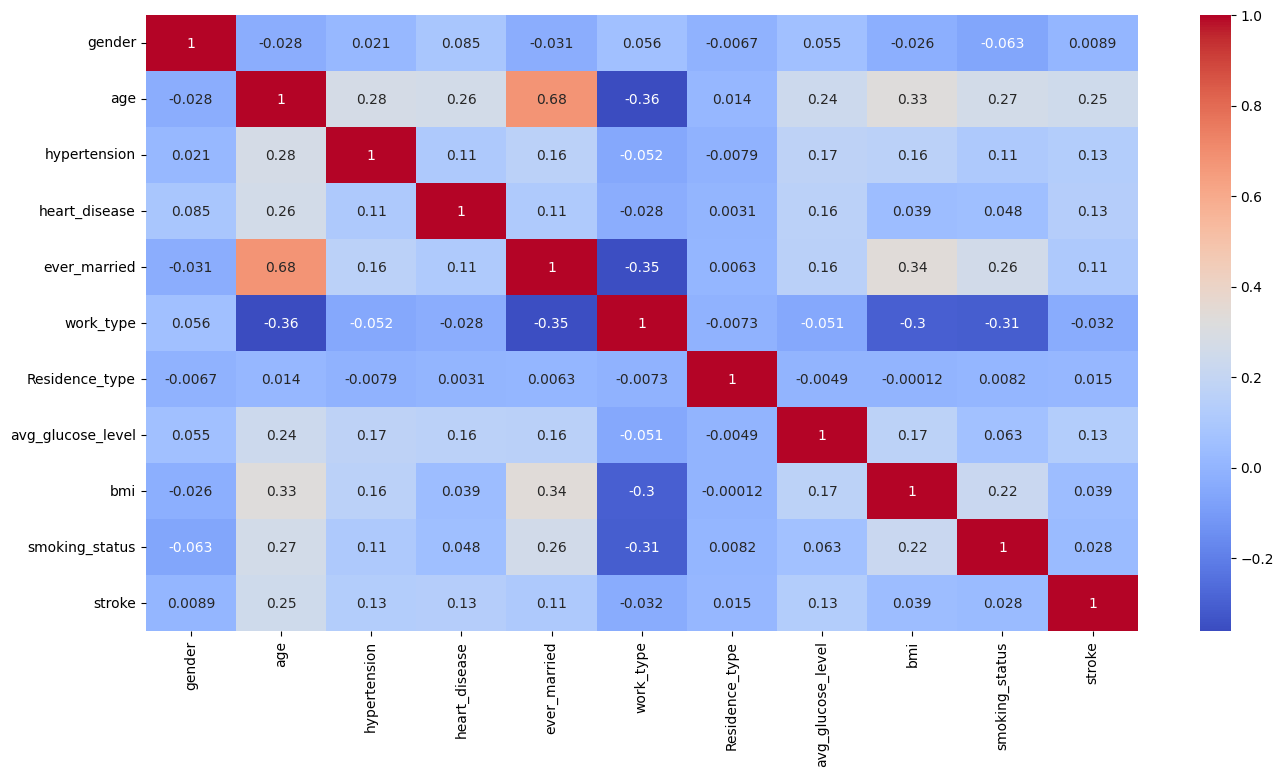

In [110]:
plt.figure(figsize=(16, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

In [111]:
df["gender"].unique()

array([1, 0, 2])

([<matplotlib.patches.Wedge at 0x16d69d557e0>,
 [Text(-0.16773471828832337, -1.087136175591971, 'No Stroke'),
  Text(0.167734882441317, 1.0871361502647208, 'Stroke')],
 [Text(-0.09149166452090364, -0.5929833685047114, '95.1%'),
  Text(0.09149175405890017, 0.5929833546898476, '4.9%')])

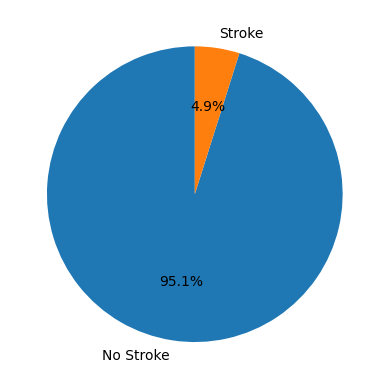

In [112]:
plt.pie(df["stroke"].value_counts(), labels=["No Stroke", "Stroke"], autopct='%1.1f%%', startangle=90)

In [113]:
X = df.drop("stroke", axis=1)
y = df["stroke"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [114]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [115]:
print(X_train.shape)
print(X_test.shape)
y_test.value_counts()

(7778, 10)
(1022, 10)


stroke
0    972
1     50
Name: count, dtype: int64

In [116]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [117]:
import warnings
warnings.filterwarnings("ignore")

In [119]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [120]:
from sklearn.linear_model import LogisticRegression
LoR = LogisticRegression()

LoR.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [121]:
y_pred = LoR.predict(X_test_scaled)

In [122]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve

In [124]:
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy Score:\n", accuracy_score(y_test, y_pred))
print("ROC AUC Score:\n", roc_auc_score(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.79      0.88       972
           1       0.15      0.72      0.25        50

    accuracy                           0.79      1022
   macro avg       0.57      0.75      0.56      1022
weighted avg       0.94      0.79      0.84      1022

Accuracy Score:
 0.7857142857142857
ROC AUC Score:
 0.7545473251028807


<Axes: >

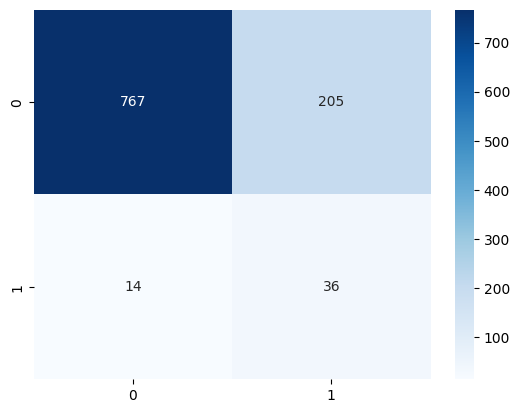

In [125]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')

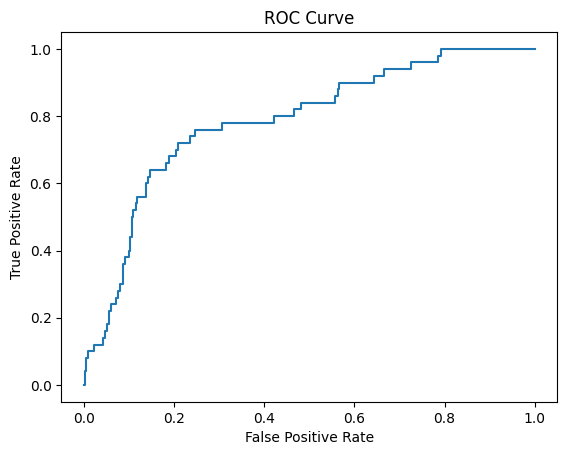

In [126]:
plt.plot(roc_curve(y_test, LoR.predict_proba(X_test_scaled)[:,1])[0], roc_curve(y_test, LoR.predict_proba(X_test_scaled)[:,1])[1])
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

<center><b>Thank You</b><center>